# HMM Baseline

This notebook implements a baseline Hidden Markov Model for detecting negation and uncertainty markers in multilingual Spanish and Catalan medical texts

- Load the preprocessed data
- Train a basic HMM model
- Evaluate performance on test data
- Save the model and results

The baseline model uses only word tokens as observations (without POS tags)


## Imports and Setup


In [1]:
import os
import sys
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import confusion_matrix
import seaborn as sns

sys.path.append("..")

from src.hmm import HMMBaseline
from src.evaluation import *
from utils.analysis import *

PATH_ROOT = os.path.dirname(os.getcwd()) 

os.makedirs(os.path.join(PATH_ROOT, "data_hmm", "results", "models"), exist_ok=True) 
os.makedirs(os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation"), exist_ok=True)

np.random.seed(42)

## Load Preprocessed Data


In [2]:
def load_processed_data(file_path):
    """Load preprocessed data from pickle file"""
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    return data

# Load the preprocessed data
train_file = os.path.join(PATH_ROOT, "data_hmm", "processed", "train_baseline.pkl")
test_file = os.path.join(PATH_ROOT, "data_hmm", "processed", "test_baseline.pkl")

train_data = load_processed_data(train_file)  
test_data = load_processed_data(test_file)  

print(f"Loaded {len(train_data['observations'])} training sequences")
print(f"Loaded {len(test_data['observations'])} test sequences")
print(f"Vocabulary size: {len(train_data['vocabulary'])}")
print(f"State space: {train_data['state_space']}")

Loaded 254 training sequences
Loaded 64 test sequences
Vocabulary size: 19904
State space: {'NEG', 'UNC', 'NSCO', 'O', 'USCO'}


## Train the Baseline HMM Model


In [3]:
hmm_model = HMMBaseline(
    state_space=train_data["state_space"],
    vocabulary=train_data["vocabulary"],
    smoothing=0.01
)

print("Training HMM model...")
hmm_model.train(train_data["observations"], train_data["states"])  # Train using observations and states

model_path = os.path.join(PATH_ROOT, "data_hmm", "results", "models", "hmm_baseline.pkl")  # Path for saving model
hmm_model.save(model_path)  # Save the trained model
print(f"Model saved to {model_path}")

Training HMM model...
Model saved to /home/tomiock/uni2024/natural_language_processing/projectNLP/hidden_markov_models/data_hmm/results/models/hmm_baseline.pkl


## Evaluate the Model


In [4]:
print("Making predictions on test data...")
test_predictions = hmm_model.predict(test_data["observations"])  # Predict on test data

print("Evaluating predictions...") # Using evaluation functions 
metrics = compute_metrics(test_data["states"], test_predictions)  # Calculate token-level metrics
entity_metrics = get_entity_based_metrics(test_data["states"], test_predictions)  # Calculate entity-level metrics

print("\nClassification Report (Token Level):")
print_classification_report(test_data["states"], test_predictions)

print("\nEntity-Level F1 Scores:")
for label, metrics_dict in entity_metrics.items():
    if label != "macro_avg":
        print(f"{label}: F1 = {metrics_dict['f1']:.4f}, Precision = {metrics_dict['precision']:.4f}, "
              f"Recall = {metrics_dict['recall']:.4f}, Support = {metrics_dict.get('support', 'N/A')}")
print(f"Macro Average: F1 = {entity_metrics['macro_avg']['f1']:.4f}\n")


# Save evaluation results
eval_path = os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation", "evaluation_baseline.json")  # Path for saving evaluation
save_metrics({
    "token_metrics": metrics,
    "entity_metrics": entity_metrics
}, eval_path)  # Save metrics to file

print(f"Evaluation results saved to {eval_path}")

Making predictions on test data...
Evaluating predictions...

Classification Report (Token Level):
              precision    recall  f1-score   support

         NEG       0.93      0.94      0.94      1152
        NSCO       0.78      0.78      0.78      3273
         UNC       0.59      0.57      0.58       194
        USCO       0.37      0.51      0.43       495
           O       0.98      0.97      0.98     42782

    accuracy                           0.95     47896
   macro avg       0.73      0.75      0.74     47896
weighted avg       0.96      0.95      0.95     47896


Entity-Level F1 Scores:
NEG: F1 = 0.9517, Precision = 0.9393, Recall = 0.9644, Support = 1123
NSCO: F1 = 0.6434, Precision = 0.6354, Recall = 0.6516, Support = 1059
UNC: F1 = 0.4317, Precision = 0.4027, Recall = 0.4651, Support = 129
USCO: F1 = 0.1720, Precision = 0.1600, Recall = 0.1860, Support = 129
Macro Average: F1 = 0.5497

Evaluation results saved to /home/tomiock/uni2024/natural_language_processing/p

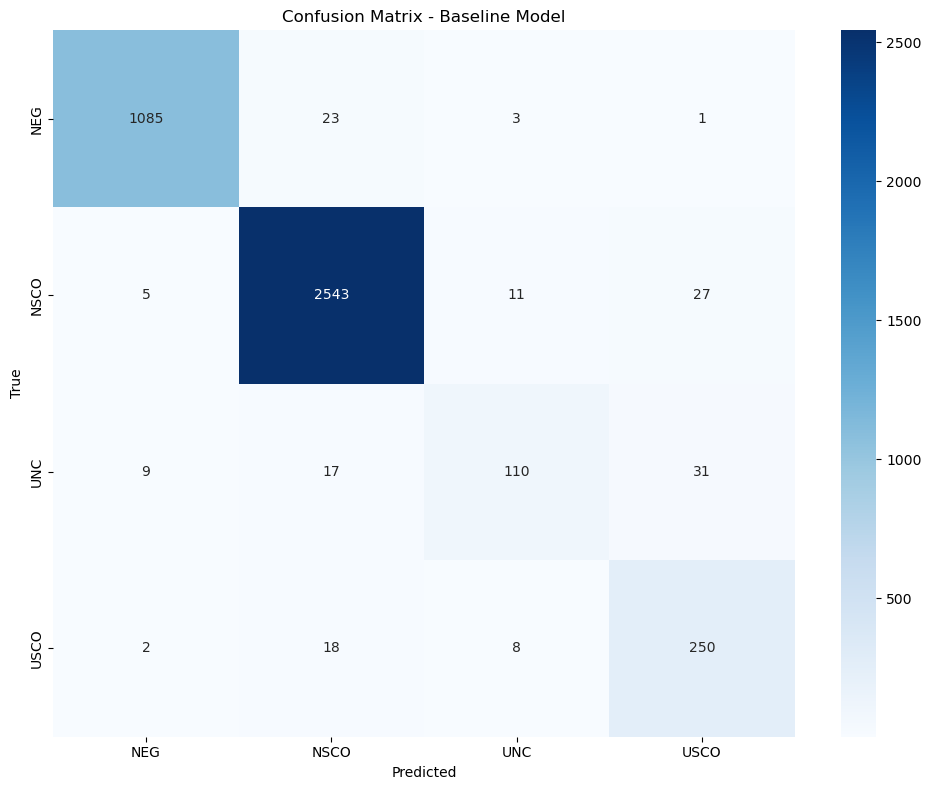

In [5]:
# Flatten true states and predicted states
flat_true_states = [tag for seq in test_data["states"] for tag in seq]
flat_pred_states = [tag for seq in test_predictions for tag in seq]

# Get unique labels
labels = sorted(test_data["state_space"])

# Remove 'O' tag from labels
labels = [label for label in labels if label != 'O']
cm_filtered = confusion_matrix(flat_true_states, flat_pred_states, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_filtered, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline Model')
plt.tight_layout()
plt.savefig(os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation", "confusion_matrix_baseline_filtered.png"))
plt.show()

## Language-Specific Analysis


In [6]:
def extract_language_info(data):
    token_languages = []

    for sequence in data["sequences"]:
        seq_langs = []
        for token in sequence["tokens"]:
            seq_langs.append(token.get("language", "es"))  # Default to Spanish if not specified
        token_languages.append(seq_langs)
    
    return token_languages

token_languages = extract_language_info(test_data)  # Get language information

language_metrics = analyze_by_language(
    test_data["states"],
    test_predictions,
    token_languages
)

print("\nLanguage-Specific Performance:")
print(f"Spanish Token-level F1: {language_metrics['spanish']['macro_avg']['f1']:.4f}")
print(f"Catalan Token-level F1: {language_metrics['catalan']['macro_avg']['f1']:.4f}")

eval_path_lang = os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation", "evaluation_baseline_language.json")  # Path for language metrics
save_metrics(language_metrics, eval_path_lang)  # Save language-specific evaluation


Language-Specific Performance:
Spanish Token-level F1: 0.7408
Catalan Token-level F1: 0.7425


## Visualize Top Emission Probabilities


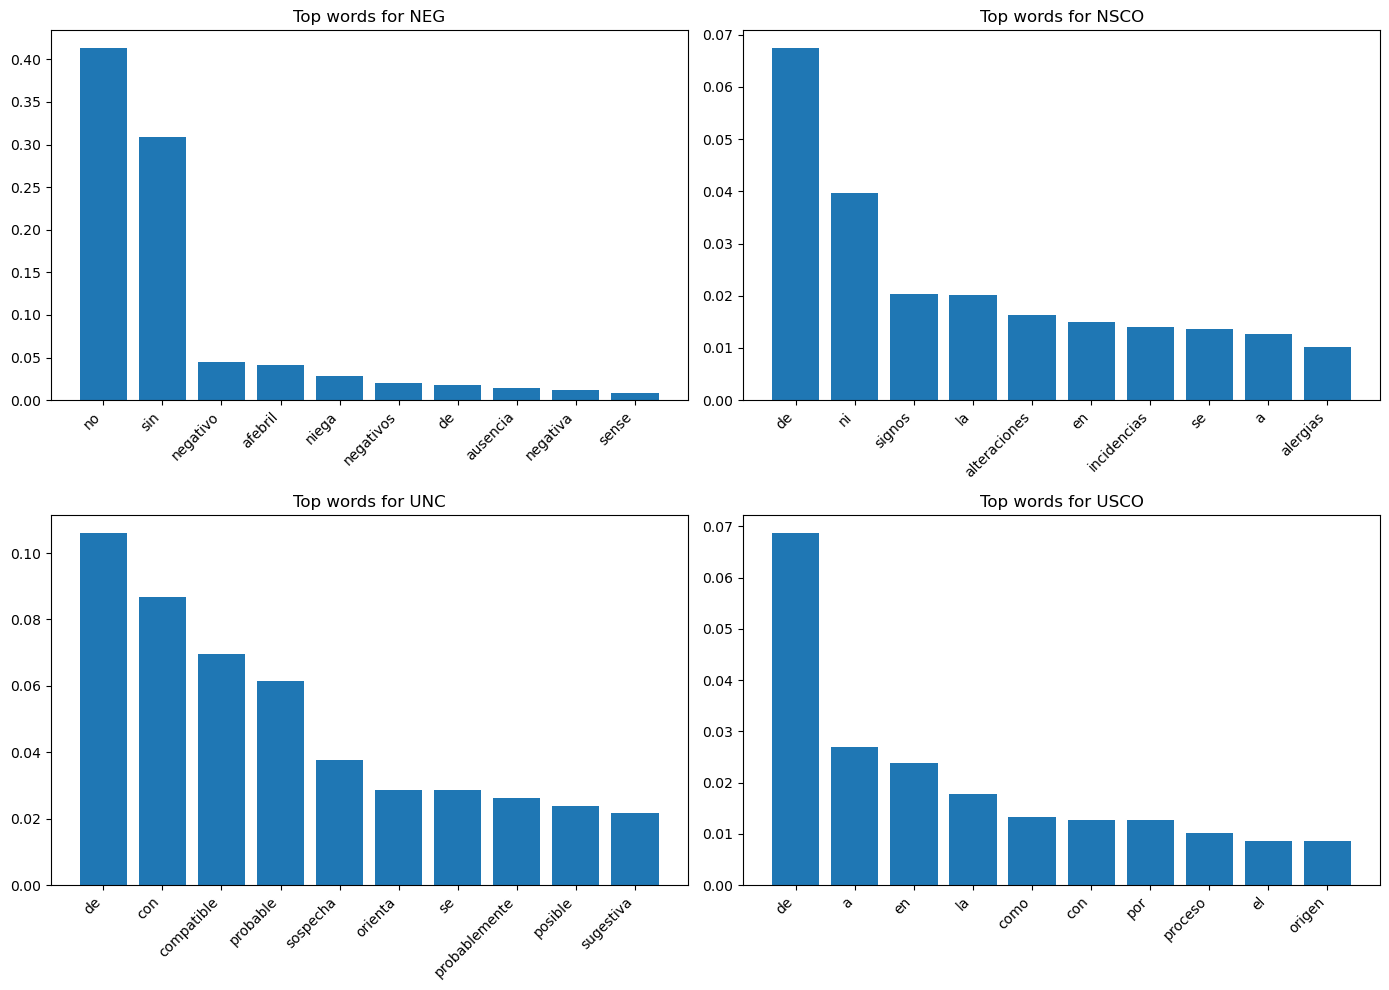

In [7]:
def get_top_words(state_idx, n=10):
    """Function to find top words for each state"""
    probs = hmm_model.emission_probs[state_idx, :]  # Probabilities for  state
    top_indices = np.argsort(probs)[-n:][::-1]  # Descending order indices
    top_words = [hmm_model.vocabulary[i] for i in top_indices]  # Get words for indices
    top_probs = [probs[i] for i in top_indices]  # Get corresponding probabilities
    return top_words, top_probs

plt.figure(figsize=(14, 10))

states_to_plot = ["NEG", "NSCO", "UNC", "USCO"]
for i, state in enumerate(states_to_plot):
    plt.subplot(2, 2, i+1) 
    if state in hmm_model.state_to_idx:
        state_idx = hmm_model.state_to_idx[state]  
        words, probs = get_top_words(state_idx, 10)
        
        plt.bar(range(len(words)), probs)  
        plt.xticks(range(len(words)), words, rotation=45, ha="right")  
        plt.title(f"Top words for {state}")  
        plt.tight_layout()  

plt.tight_layout()
plt.savefig(os.path.join(PATH_ROOT, "data_hmm", "results", "evaluation", "baseline_top_words.png")) 
plt.show()

## Examples


In [8]:
analysis = find_examples_and_patterns(test_data["states"], test_predictions, test_data["observations"])

# Display results
print("-- SUCCESSFUL PREDICTIONS --")
print("Examples where the baseline model correctly identified negation/uncertainty markers:\n")
for i, example in enumerate(analysis["success"]):
    print(f"Success Example {i+1}:")
    print(format_vertical_example(example))
    print("\n")

-- SUCCESSFUL PREDICTIONS --
Examples where the baseline model correctly identified negation/uncertainty markers:

Success Example 1:
Example ID: 22-32
----------------------------------------------------------------------
TOKEN                TRUE         PREDICTED    CORRECT 
----------------------------------------------------------------------
no                   NEG          NEG          T       
se                   NSCO         NSCO         T       
observan             NSCO         NSCO         T       
condensaciones       NSCO         NSCO         T       
ni                   NSCO         NSCO         T       
otras                NSCO         NSCO         T       
lesiones             NSCO         NSCO         T       
parenquimatosas      NSCO         NSCO         T       
-rx                  O            O            T       
de                   O            O            T       


Success Example 2:
Example ID: 16-6
----------------------------------------------------

In [9]:
analysis = find_examples_and_patterns(test_data["states"], test_predictions, test_data["observations"]) # true_labels, pred_labels, observations

print("\n-- CHALLENGING CASES --")
print("Examples where the baseline model struggled with negation/uncertainty markers:\n")
for i, example in enumerate(analysis["errors"]):
    print(f"Error Example {i+1}:")
    print(format_vertical_example(example))
    print("\n")


-- CHALLENGING CASES --
Examples where the baseline model struggled with negation/uncertainty markers:

Error Example 1:
Example ID: 1-35
----------------------------------------------------------------------
TOKEN                TRUE         PREDICTED    CORRECT 
----------------------------------------------------------------------
cardiotoracico       O            O            T       
no                   NEG          NEG          T       
aumentado            NSCO         O            F       
lt0.5                O            O            T       
senos                O            O            T       
costofrenicos        O            O            T       
libres               O            O            T       
no                   NEG          NEG          T       
condensaciones       NSCO         NSCO         T       
parenquimatosas      NSCO         NSCO         T       


Error Example 2:
Example ID: 2-27
-------------------------------------------------------------------

In [10]:
print("\n-- COMMON ERROR PATTERNS --")
print("Most frequent patterns where model predictions differ from ground truth:")
print(f"{'TRUE TRANSITION':<20} {'PREDICTED AS':<16} {'PREDICTION':<16} {'COUNT':<10}")
print("-" * 65)
for true_trans, pred_trans, count in analysis["patterns"]:
    print(f"{true_trans:<20} {'predicted as':<16} {pred_trans:<16} {count} occurrences")

print("\n-- TRANSITION ANALYSIS --")
print("Accuracy of different state transitions in the baseline model:")
print(f"{'TRANSITION':<15} {'ACCURACY':<10} {'CORRECT/TOTAL':<15}")
print("-" * 45)
for transition, stats in analyze_transitions(test_data["states"], test_predictions):
    accuracy = stats["accuracy"] * 100
    correct_total = f"{stats['correct']}/{stats['total']}"
    print(f"{transition:<15} {accuracy:.1f}%      {correct_total:<15}")


-- COMMON ERROR PATTERNS --
Most frequent patterns where model predictions differ from ground truth:
TRUE TRANSITION      PREDICTED AS     PREDICTION       COUNT     
-----------------------------------------------------------------
NSCO->NSCO           predicted as     O->O             397 occurrences
O->O                 predicted as     NSCO->NSCO       374 occurrences
O->O                 predicted as     USCO->USCO       290 occurrences
NSCO->NSCO           predicted as     NSCO->O          177 occurrences
USCO->USCO           predicted as     O->O             148 occurrences
NSCO->O              predicted as     NSCO->NSCO       125 occurrences
O->NSCO              predicted as     O->O             64 occurrences
NEG->O               predicted as     NEG->NSCO        61 occurrences

-- TRANSITION ANALYSIS --
Accuracy of different state transitions in the baseline model:
TRANSITION      ACCURACY   CORRECT/TOTAL  
---------------------------------------------
O->O            97.9%